# optimize_result_compare

`optimize_check_data_compare_v3.ipynb` から、**比較表作成と簡単なグラフ作成**の部分だけを独立させた notebook です。

この notebook でやること:
1. 各手法 (`gpr`, `cmaes`, `random`, `ga`) の `summary_*.json` と `timing_*.csv` を読む
2. 比較用の主表・補助表を作る
3. 簡単な棒グラフを作る
4. 必要なら CSV に保存する


## 事前準備

必要なら先に以下を実行してください。

```bash
pip install polars matplotlib
```


In [51]:
from pathlib import Path
import json
import polars as pl

pl.Config.set_tbl_rows(50)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(120)

import matplotlib.pyplot as plt
from math import ceil

import pyarrow.feather as feather
import pyarrow as pa


In [52]:
# ===== ここを必要に応じて変更 =====
BASE_DIR = Path(".")
NETWORK_NAME = "ba_1000"   # "ba_1000" / "facebook" / "wiki-vote"
METHODS = ["gpr", "cmaes", "random", "ga"]   # None にすると自動検出

EXPERIMENT_DIR = BASE_DIR / f"optimize_test_{NETWORK_NAME}"
EXPERIMENT_DIR


PosixPath('optimize_test_ba_1000')

In [53]:
def resolve_methods(experiment_dir: Path, methods=None):
    if methods is not None:
        return methods
    return sorted(
        p.name for p in experiment_dir.iterdir()
        if p.is_dir() and (p / "logs").exists()
    )

methods = resolve_methods(EXPERIMENT_DIR, METHODS)
methods


['gpr', 'cmaes', 'random', 'ga']

## 1. データ読み込み用関数

- `summary_*.json` から **best score / best params / total time**
- `timing_*.csv` から **trial ごとの値や時間**
を取得します。


In [54]:
def load_summary(method: str, experiment_dir: Path) -> dict | None:
    summary_path = experiment_dir / method / "logs" / f"summary_{method}.json"
    if not summary_path.exists():
        print(f"[skip] summary not found: {summary_path}")
        return None

    with open(summary_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    row = {
        "method": method,
        "network": obj.get("network"),
        "best_score": obj.get("best_score"),
        "total_time_sec": obj.get("total_optimization_sec"),
        "mean_trial_time_sec": obj.get("mean_trial_sec"),
        "mean_simulation_time_sec": obj.get("mean_simulation_sec"),
        "mean_score_calc_time_sec": obj.get("mean_score_sec"),
        "n_trials_total": obj.get("n_trials_total"),
        "n_trials_complete": obj.get("n_trials_complete"),
        "best_certainty": (obj.get("best_params") or {}).get("certainty"),
        "best_effectiveness": (obj.get("best_params") or {}).get("effectiveness"),
        "summary_path": str(summary_path),
    }
    return row


def load_timing(method: str, experiment_dir: Path) -> pl.DataFrame | None:
    timing_path = experiment_dir / method / "logs" / f"timing_{method}.csv"
    if not timing_path.exists():
        print(f"[skip] timing not found: {timing_path}")
        return None

    df = pl.read_csv(timing_path)

    numeric_cols = [
        "value",
        "certainty",
        "effectiveness",
        "trial_elapsed_sec",
        "simulation_elapsed_sec",
        "score_elapsed_sec",
    ]

    existing_numeric_cols = [c for c in numeric_cols if c in df.columns]

    if existing_numeric_cols:
        df = df.with_columns(
            [pl.col(c).cast(pl.Float64, strict=False) for c in existing_numeric_cols]
        )

    return df


In [55]:
summary_rows = []
timing_map = {}

for method in methods:
    row = load_summary(method, EXPERIMENT_DIR)
    timing_df = load_timing(method, EXPERIMENT_DIR)

    if row is not None:
        summary_rows.append(row)
    if timing_df is not None:
        timing_map[method] = timing_df

summary_df = pl.DataFrame(summary_rows) if summary_rows else pl.DataFrame()
summary_df


method,network,best_score,total_time_sec,mean_trial_time_sec,mean_simulation_time_sec,mean_score_calc_time_sec,n_trials_total,n_trials_complete,best_certainty,best_effectiveness,summary_path
str,str,f64,f64,f64,f64,f64,i64,i64,f64,f64,str
"""gpr""","""ba_1000""",0.00001,570.982117,5.684507,5.407225,0.003169,100,100,0.865997,0.799329,"""optimize_test_ba_1000/gpr/logs/summary_gpr.json"""
"""cmaes""","""ba_1000""",0.00001,540.173041,5.375943,5.358467,0.003593,100,100,0.975629,0.518127,"""optimize_test_ba_1000/cmaes/logs/summary_cmaes.json"""
"""random""","""ba_1000""",0.0,556.467644,5.539026,5.529798,0.003414,100,100,0.546551,0.948608,"""optimize_test_ba_1000/random/logs/summary_random.json"""
"""ga""","""ba_1000""",0.00001,557.858956,5.552996,5.535376,0.003259,100,100,0.865997,0.799329,"""optimize_test_ba_1000/ga/logs/summary_ga.json"""


## 2. trial 全体の統計量を作る

ここでは `timing_*.csv` から、各手法について

- Mean Trial Score
- Median Trial Score
- Std Trial Score
- Worst Trial Score

を計算します。

> `state == COMPLETE` の行だけを使います。


In [56]:
def build_trial_stats(method: str, timing_df: pl.DataFrame) -> dict:
    if "state" in timing_df.columns:
        complete_df = timing_df.filter(pl.col("state").str.contains("COMPLETE"))
    else:
        complete_df = timing_df

    if complete_df.height == 0:
        return {
            "method": method,
            "mean_trial_score": None,
            "median_trial_score": None,
            "std_trial_score": None,
            "worst_trial_score": None,
        }

    return {
        "method": method,
        "mean_trial_score": complete_df["value"].mean(),
        "median_trial_score": complete_df["value"].median(),
        "std_trial_score": complete_df["value"].std(),
        "worst_trial_score": complete_df["value"].max(),
    }


trial_stats_rows = [
    build_trial_stats(method, timing_df)
    for method, timing_df in timing_map.items()
]

trial_stats_df = pl.DataFrame(trial_stats_rows) if trial_stats_rows else pl.DataFrame()
trial_stats_df


method,mean_trial_score,median_trial_score,std_trial_score,worst_trial_score
str,f64,f64,f64,f64
"""gpr""",0.000028,0.00002,0.000015,0.00009
"""cmaes""",0.000053,0.00005,0.000023,0.00012
"""random""",0.000057,0.000055,0.000025,0.00012
"""ga""",0.000057,0.000055,0.000025,0.00012


## 3. 主表を作る

まずは **性能 + 時間 + 最良パラメータ** をまとめた主表を作ります。

この表が、最初に見るべき比較表です。


In [57]:
if summary_df.height > 0 and trial_stats_df.height > 0:
    comparison_df = (
        summary_df.join(trial_stats_df, on="method", how="left")
        .select([
            "method",#手法
            "best_score",#最良スコア
            "mean_trial_score",#平均スコア
            "median_trial_score",#中央値スコア
            "std_trial_score",#スコアの標準偏差 ばらつき
            "worst_trial_score",#最悪スコア
            "total_time_sec",#合計時間
            "mean_trial_time_sec",#平均 trial 時間
            "mean_simulation_time_sec",#平均 Rust シミュレーション時間
            "mean_score_calc_time_sec",#平均 スコア計算時間
            "n_trials_total",#総試行回数
            "n_trials_complete",#完了した試行回数
            "best_certainty",#最良の確実性 x1
            "best_effectiveness",#最良の効果 x2　
        ])
        .sort(["best_score", "total_time_sec"], descending=[False, False])
        .with_row_index("rank", offset=1)
    )
else:
    comparison_df = pl.DataFrame()

comparison_df


rank,method,best_score,mean_trial_score,median_trial_score,std_trial_score,worst_trial_score,total_time_sec,mean_trial_time_sec,mean_simulation_time_sec,mean_score_calc_time_sec,n_trials_total,n_trials_complete,best_certainty,best_effectiveness
u32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64
1,"""random""",0.0,0.000057,0.000055,0.000025,0.00012,556.467644,5.539026,5.529798,0.003414,100,100,0.546551,0.948608
2,"""cmaes""",0.00001,0.000053,0.00005,0.000023,0.00012,540.173041,5.375943,5.358467,0.003593,100,100,0.975629,0.518127
3,"""ga""",0.00001,0.000057,0.000055,0.000025,0.00012,557.858956,5.552996,5.535376,0.003259,100,100,0.865997,0.799329
4,"""gpr""",0.00001,0.000028,0.00002,0.000015,0.00009,570.982117,5.684507,5.407225,0.003169,100,100,0.865997,0.799329


In [58]:
if summary_df.height > 0 and trial_stats_df.height > 0:
    comparison_summary_df = (
        summary_df.join(trial_stats_df, on="method", how="left")
        .select([
            "method",#手法
            "best_score",#最良スコア
            "mean_trial_score",#平均スコア
            "std_trial_score",#スコアの標準偏差 ばらつき
            "worst_trial_score",#最悪スコア
            "total_time_sec",#合計時間
            "mean_trial_time_sec",#平均 trial 時間
            "best_certainty",#最良の確実性 x1
            "best_effectiveness",#最良の効果 x2　
        ])
        .sort(["best_score", "total_time_sec"], descending=[False, False])
        .with_row_index("rank", offset=1)
    )
else:
    comparison_summary_df = pl.DataFrame()

comparison_summary_df

rank,method,best_score,mean_trial_score,std_trial_score,worst_trial_score,total_time_sec,mean_trial_time_sec,best_certainty,best_effectiveness
u32,str,f64,f64,f64,f64,f64,f64,f64,f64
1,"""random""",0.0,0.000057,0.000025,0.00012,556.467644,5.539026,0.546551,0.948608
2,"""cmaes""",0.00001,0.000053,0.000023,0.00012,540.173041,5.375943,0.975629,0.518127
3,"""ga""",0.00001,0.000057,0.000025,0.00012,557.858956,5.552996,0.865997,0.799329
4,"""gpr""",0.00001,0.000028,0.000015,0.00009,570.982117,5.684507,0.865997,0.799329


## 4. 見やすい補助表

### 性能だけを見る表
- Best Score
- Mean / Median / Std
- Worst Trial Score

### 時間だけを見る表
- Total Time
- Avg Time / Trial
- Avg Simulation Time
- Avg Score Calc Time


In [59]:
performance_df = (
    comparison_df.select([
        "rank",
        "method",
        "best_score",
        "mean_trial_score",
        "median_trial_score",
        "std_trial_score",
        "worst_trial_score",
        "best_certainty",
        "best_effectiveness",
    ])
    if comparison_df.height > 0 else pl.DataFrame()
)

timing_df = (
    comparison_df.select([
        "rank",
        "method",
        "total_time_sec",
        "mean_trial_time_sec",
        "mean_simulation_time_sec",
        "mean_score_calc_time_sec",
        "n_trials_total",
        "n_trials_complete",
    ])
    if comparison_df.height > 0 else pl.DataFrame()
)

performance_df, timing_df


(shape: (4, 9)
 ┌──────┬────────┬───────────┬───────────┬───────────┬───────────┬───────────┬───────────┬──────────┐
 │ rank ┆ method ┆ best_scor ┆ mean_tria ┆ median_tr ┆ std_trial ┆ worst_tri ┆ best_cert ┆ best_eff │
 │ ---  ┆ ---    ┆ e         ┆ l_score   ┆ ial_score ┆ _score    ┆ al_score  ┆ ainty     ┆ ectivene │
 │ u32  ┆ str    ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ss       │
 │      ┆        ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ ---      │
 │      ┆        ┆           ┆           ┆           ┆           ┆           ┆           ┆ f64      │
 ╞══════╪════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪══════════╡
 │ 1    ┆ random ┆ 0.0       ┆ 0.000057  ┆ 0.000055  ┆ 0.000025  ┆ 0.00012   ┆ 0.546551  ┆ 0.948608 │
 │ 2    ┆ cmaes  ┆ 0.00001   ┆ 0.000053  ┆ 0.00005   ┆ 0.000023  ┆ 0.00012   ┆ 0.975629  ┆ 0.518127 │
 │ 3    ┆ ga     ┆ 0.00001   ┆ 0.000057  ┆ 0.000055  ┆ 0.000025  ┆ 

## 5. 必要なら CSV に保存する

このセルを実行すると、比較表を `compare_tables/` に保存します。


In [60]:
OUTPUT_DIR = EXPERIMENT_DIR / "compare_tables"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

comparison_path = OUTPUT_DIR / f"comparison_{NETWORK_NAME}.csv"
performance_path = OUTPUT_DIR / f"performance_{NETWORK_NAME}.csv"
timing_path = OUTPUT_DIR / f"timing_{NETWORK_NAME}.csv"

if comparison_df.height > 0:
    comparison_df.write_csv(comparison_path)

if performance_df.height > 0:
    performance_df.write_csv(performance_path)

if timing_df.height > 0:
    timing_df.write_csv(timing_path)

print("saved files:")
for p in [comparison_path, performance_path, timing_path]:
    print(" -", p)


saved files:
 - optimize_test_ba_1000/compare_tables/comparison_ba_1000.csv
 - optimize_test_ba_1000/compare_tables/performance_ba_1000.csv
 - optimize_test_ba_1000/compare_tables/timing_ba_1000.csv


## 6. 使い方メモ

### BA1000 を見る
```python
NETWORK_NAME = "ba_1000"
```

### Facebook を見る
```python
NETWORK_NAME = "facebook"
```

### Wiki-vote を見る
```python
NETWORK_NAME = "wiki-vote"
```

### メモ
- **最初に見るべきなのは `comparison_df`**
- 発表や論文では、まず `comparison_df` をベースにして、
  必要に応じて `performance_df` と `timing_df` を分けて出すと見やすいです


## 可視化

## 7. 簡単なグラフを作る

まずは比較表 `comparison_df` から、**見やすい簡単な棒グラフ**を作ります。

この notebook では次の4種類を用意しています。

- Best Score
- Mean Trial Score
- Total Optimization Time
- Avg Time / Trial

※ 値が小さいほど良い指標が多いので、棒が低い方が良いと読めます。


In [61]:
if comparison_df.height == 0:
    raise ValueError("comparison_df が空です。前のセルを先に実行してください。")

plot_df = comparison_df.sort("rank")
plot_df


rank,method,best_score,mean_trial_score,median_trial_score,std_trial_score,worst_trial_score,total_time_sec,mean_trial_time_sec,mean_simulation_time_sec,mean_score_calc_time_sec,n_trials_total,n_trials_complete,best_certainty,best_effectiveness
u32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64
1,"""random""",0.0,0.000057,0.000055,0.000025,0.00012,556.467644,5.539026,5.529798,0.003414,100,100,0.546551,0.948608
2,"""cmaes""",0.00001,0.000053,0.00005,0.000023,0.00012,540.173041,5.375943,5.358467,0.003593,100,100,0.975629,0.518127
3,"""ga""",0.00001,0.000057,0.000055,0.000025,0.00012,557.858956,5.552996,5.535376,0.003259,100,100,0.865997,0.799329
4,"""gpr""",0.00001,0.000028,0.00002,0.000015,0.00009,570.982117,5.684507,5.407225,0.003169,100,100,0.865997,0.799329


In [62]:
plot_df.columns

['rank',
 'method',
 'best_score',
 'mean_trial_score',
 'median_trial_score',
 'std_trial_score',
 'worst_trial_score',
 'total_time_sec',
 'mean_trial_time_sec',
 'mean_simulation_time_sec',
 'mean_score_calc_time_sec',
 'n_trials_total',
 'n_trials_complete',
 'best_certainty',
 'best_effectiveness']

In [63]:
def to_pylist(df: pl.DataFrame, col: str):
    return df.get_column(col).to_list()

methods_plot = to_pylist(plot_df, "method")
best_scores_plot = to_pylist(plot_df, "best_score")
mean_scores_plot = to_pylist(plot_df, "mean_trial_score")
total_time_plot = to_pylist(plot_df, "total_time_sec")
avg_trial_time_plot = to_pylist(plot_df, "mean_trial_time_sec")


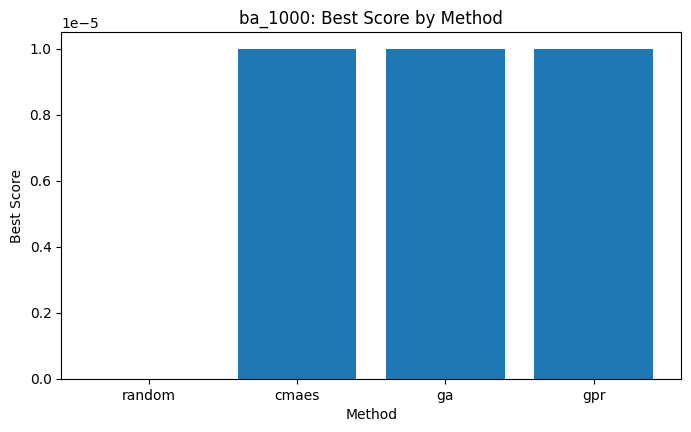

In [64]:
plt.figure(figsize=(8, 4.5))
plt.bar(methods_plot, best_scores_plot)
plt.title(f"{NETWORK_NAME}: Best Score by Method")
plt.xlabel("Method")
plt.ylabel("Best Score")
plt.show()


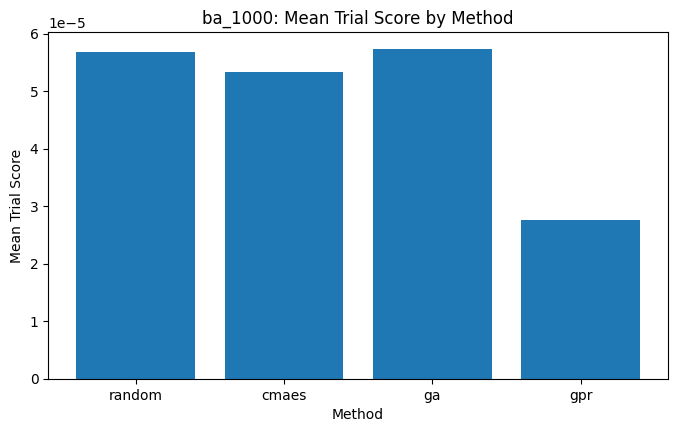

In [65]:
plt.figure(figsize=(8, 4.5))
plt.bar(methods_plot, mean_scores_plot)
plt.title(f"{NETWORK_NAME}: Mean Trial Score by Method")
plt.xlabel("Method")
plt.ylabel("Mean Trial Score")
plt.show()


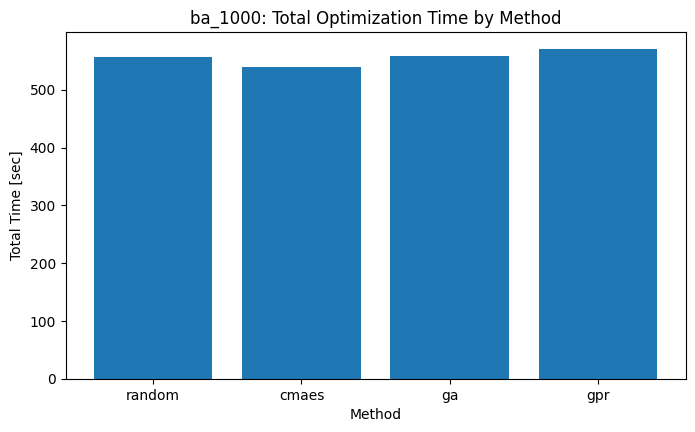

In [66]:
plt.figure(figsize=(8, 4.5))
plt.bar(methods_plot, total_time_plot)
plt.title(f"{NETWORK_NAME}: Total Optimization Time by Method")
plt.xlabel("Method")
plt.ylabel("Total Time [sec]")
plt.show()


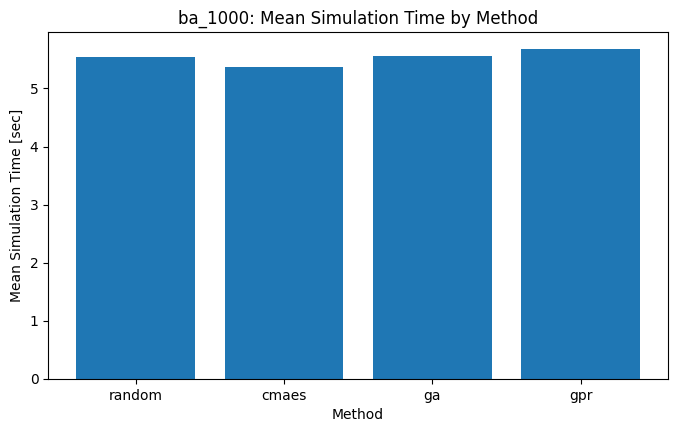

In [67]:
plt.figure(figsize=(8, 4.5))
plt.bar(methods_plot, avg_trial_time_plot)
plt.title(f"{NETWORK_NAME}: Mean Simulation Time by Method")
plt.xlabel("Method")
plt.ylabel("Mean Simulation Time [sec]")
plt.show()


### まとめて見たい場合

4つをまとめて確認したいとき用のセルです。


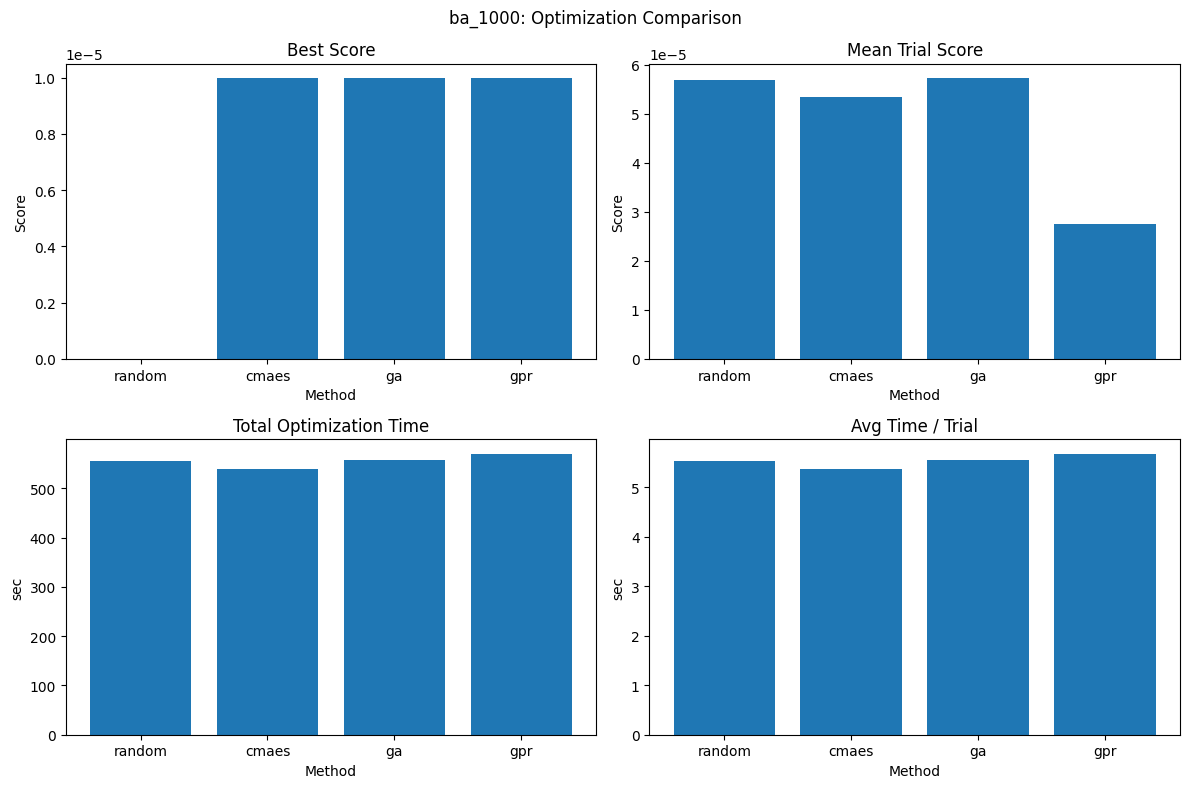

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].bar(methods_plot, best_scores_plot)
axes[0, 0].set_title("Best Score")
axes[0, 0].set_xlabel("Method")
axes[0, 0].set_ylabel("Score")

axes[0, 1].bar(methods_plot, mean_scores_plot)
axes[0, 1].set_title("Mean Trial Score")
axes[0, 1].set_xlabel("Method")
axes[0, 1].set_ylabel("Score")

axes[1, 0].bar(methods_plot, total_time_plot)
axes[1, 0].set_title("Total Optimization Time")
axes[1, 0].set_xlabel("Method")
axes[1, 0].set_ylabel("sec")

axes[1, 1].bar(methods_plot, avg_trial_time_plot)
axes[1, 1].set_title("Avg Time / Trial")
axes[1, 1].set_xlabel("Method")
axes[1, 1].set_ylabel("sec")

plt.suptitle(f"{NETWORK_NAME}: Optimization Comparison")
plt.tight_layout()
plt.show()


In [69]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# 表が空なら止める
if comparison_summary_df.height == 0:
    raise ValueError("comparison_summary_df が空です。前のセルを先に実行してください。")

# rank順に並べる
plot_df = comparison_summary_df.sort("rank")

# Python list 化
methods_plot = plot_df["method"].to_list()
best_scores_plot = plot_df["best_score"].to_list()
mean_scores_plot = plot_df["mean_trial_score"].to_list()
std_scores_plot = plot_df["std_trial_score"].to_list()
worst_scores_plot = plot_df["worst_trial_score"].to_list()
total_time_plot = plot_df["total_time_sec"].to_list()
mean_trial_time_plot = plot_df["mean_trial_time_sec"].to_list()
best_certainty_plot = plot_df["best_certainty"].to_list()
best_effectiveness_plot = plot_df["best_effectiveness"].to_list()

x = list(range(len(methods_plot)))

method_label_map = {
    "random": "Random",
    "cmaes": "CMA-ES",
    "ga": "GA",
    "gpr": "GPR",
}

method_color_map = {
    "random": "tab:blue",
    "cmaes": "tab:orange",
    "ga": "tab:green",
    "gpr": "tab:red",
}

display_methods_plot = [method_label_map.get(m, m) for m in methods_plot]
colors_plot = [method_color_map.get(m, "tab:gray") for m in methods_plot]

# 文字重なりを避けるための注釈オフセット
annotation_offset_map = {
    "random": (6, 2),
    "cmaes": (6, 2),
    "ga": (6, 10),
    "gpr": (6, -12),
}

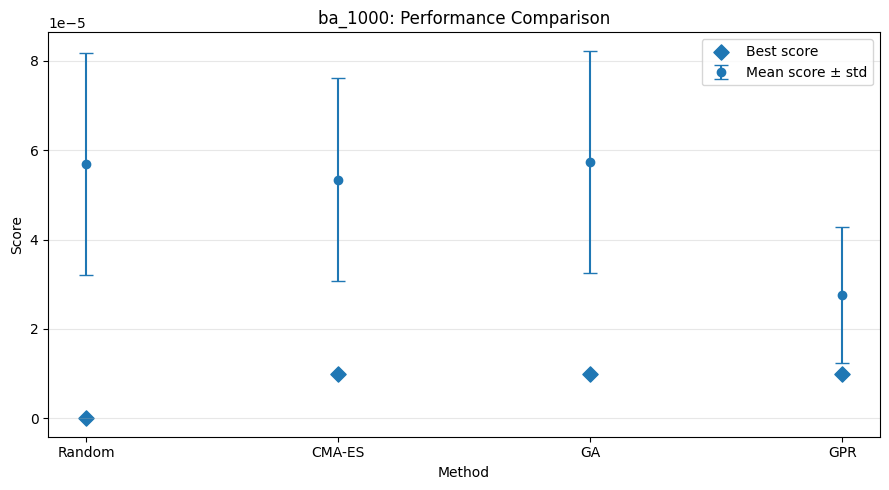

In [89]:
plt.figure(figsize=(9, 5))

# 平均 ± 標準偏差
plt.errorbar(
    x,
    mean_scores_plot,
    yerr=std_scores_plot,
    fmt="o",
    capsize=5,
    label="Mean score ± std"
)

# best score
plt.scatter(
    x,
    best_scores_plot,
    marker="D",
    s=60,
    label="Best score"
)

plt.xticks(x, display_methods_plot)
plt.xlabel("Method")
plt.ylabel("Score")
plt.title(f"{NETWORK_NAME}: Performance Comparison")

plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

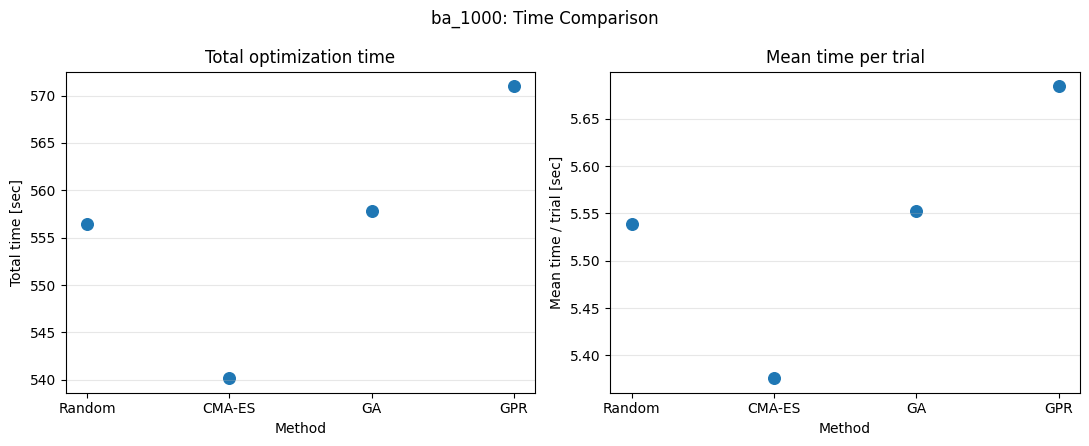

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(x, total_time_plot, s=70)
axes[0].set_xticks(x)
axes[0].set_xticklabels(display_methods_plot)
axes[0].set_xlabel("Method")
axes[0].set_ylabel("Total time [sec]")
axes[0].set_title("Total optimization time")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].scatter(x, mean_trial_time_plot, s=70)
axes[1].set_xticks(x)
axes[1].set_xticklabels(display_methods_plot)
axes[1].set_xlabel("Method")
axes[1].set_ylabel("Mean time / trial [sec]")
axes[1].set_title("Mean time per trial")
axes[1].grid(True, axis="y", alpha=0.3)

plt.suptitle(f"{NETWORK_NAME}: Time Comparison")
plt.tight_layout()
plt.show()

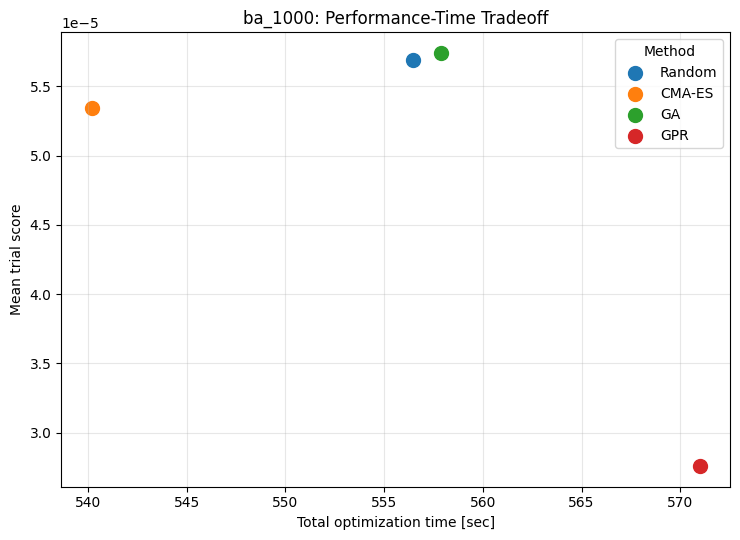

In [82]:
plt.figure(figsize=(7.5, 5.5))

for i, method in enumerate(methods_plot):
    plt.scatter(
        total_time_plot[i],
        mean_scores_plot[i],
        s=100,
        color=method_color_map.get(method, "tab:gray"),
        label=method_label_map.get(method, method)
    )

plt.xlabel("Total optimization time [sec]")
plt.ylabel("Mean trial score")
plt.title(f"{NETWORK_NAME}: Performance-Time Tradeoff")
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.grid(True, alpha=0.3)

# 重複しない legend
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), title="Method")

plt.tight_layout()
plt.show()

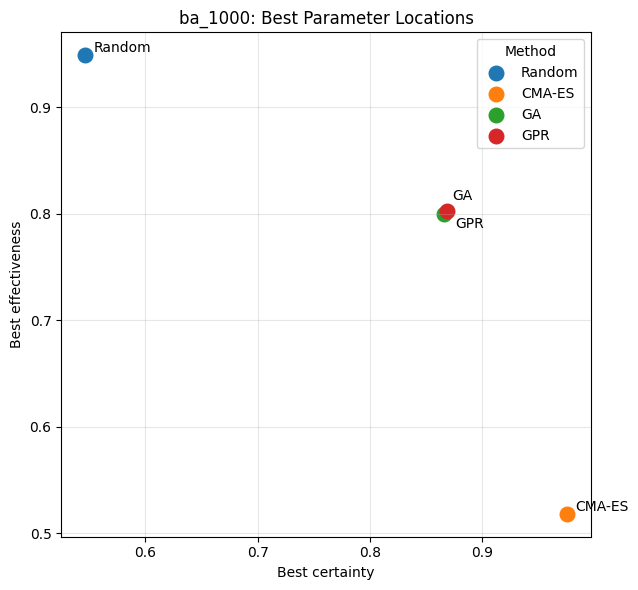

In [90]:
# 表示用にだけ少しずらす
display_best_certainty = best_certainty_plot.copy()
display_best_effectiveness = best_effectiveness_plot.copy()

# 同一点に重なりやすいものを少しだけずらす
seen_points = {}
for i, method in enumerate(methods_plot):
    key = (best_certainty_plot[i], best_effectiveness_plot[i])
    if key in seen_points:
        shift_count = seen_points[key]
        display_best_certainty[i] += 0.003 * shift_count
        display_best_effectiveness[i] += 0.003 * shift_count
        seen_points[key] += 1
    else:
        seen_points[key] = 1

plt.figure(figsize=(6.5, 6))

for i, method in enumerate(methods_plot):
    plt.scatter(
        display_best_certainty[i],
        display_best_effectiveness[i],
        s=110,
        color=method_color_map.get(method, "tab:gray"),
        label=method_label_map.get(method, method)
    )

for i, method in enumerate(methods_plot):
    label = method_label_map.get(method, method)
    dx, dy = annotation_offset_map.get(method, (5, 5))
    plt.annotate(
        label,
        (display_best_certainty[i], display_best_effectiveness[i]),
        textcoords="offset points",
        xytext=(dx, dy)
    )

plt.xlabel("Best certainty")
plt.ylabel("Best effectiveness")
plt.title(f"{NETWORK_NAME}: Best Parameter Locations")
plt.grid(True, alpha=0.3)

handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), title="Method")

plt.tight_layout()
plt.show()

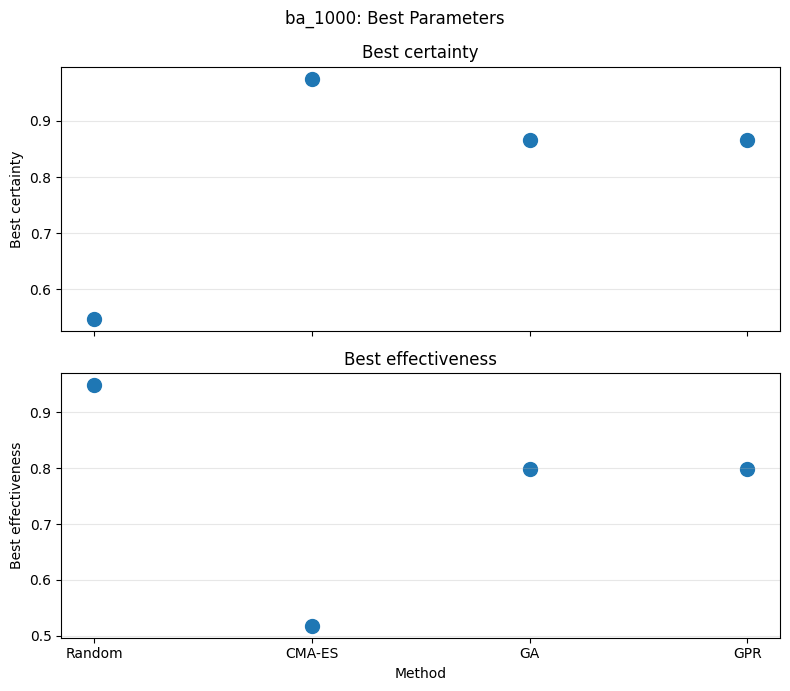

In [88]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# certainty
for i, method in enumerate(methods_plot):
    axes[0].scatter(
        i,
        best_certainty_plot[i],
        s=100,
        color="tab:blue"
    )
axes[0].set_ylabel("Best certainty")
axes[0].set_title("Best certainty")
axes[0].grid(True, axis="y", alpha=0.3)

# effectiveness
for i, method in enumerate(methods_plot):
    axes[1].scatter(
        i,
        best_effectiveness_plot[i],
        s=100,
        color="tab:blue"
    )
axes[1].set_ylabel("Best effectiveness")
axes[1].set_xlabel("Method")
axes[1].set_title("Best effectiveness")
axes[1].grid(True, axis="y", alpha=0.3)

axes[1].set_xticks(x)
axes[1].set_xticklabels(display_methods_plot)

plt.suptitle(f"{NETWORK_NAME}: Best Parameters")
plt.tight_layout()
plt.show()